# 核心原理:利用基因的"天然随机分配"
想知道"LDL胆固醇升高是否导致心梗",传统RC、T成、本高、周期长。MR的逻辑是:基茵型在受孕时随机分配,不受后天混杂因素影响。携带影响LDL的SNP的人=天生"高胆固醇组",不携带=对照组,比较两组心梗发病率即可推断因果关系。
三大核心假设(违反则结论不可靠)
假设1-相关性:SNP与暴露强相关(F统计量>10,F值越大工具越强)
假设2-独立性:SNP不与混杂因素相关(蕞难验证,靠生物学知识+敏感性分析判断)
假设3-排他性:SNP只能通过暴露影响结局,无其他路径(违反此假设称"水平多效性",是MR蕞大威胁)
实cao关键3步
选工具变量:从GWAS数据库(IEU OpenGWAS)选p<5×10⁻⁸的SNP,剔除LD(r²<0.001)
获取关联数据:提取SNP-结局关联,注意暴露和结局GWAS样本不能重叠
MR分析:用TwoSampleMR包,主要方法IVW(常用但对多效性敏感)、MR-Egger(可检测多效性)、加权中位数(允许50%SNP违反假设)。必做敏感性分析:Cochran Q(异质性)、MR-Egger截距(多效性)、Leave-one-out(单SNP影响)
适用条件
✅ 有大样本GWAS支持(>10万)且暴露遗传力>5%
❌ 不适合:遗传力低、样本量小、无合适工具变量
记住:MR前提是三大假设成立,敏感性分析是验证稳健性的关键,不是走形式。

# 第一步：选工具变量
从GWAS数据里筛SNP，P < 5×10⁻⁸，去连锁不平衡，F统计量 > 10。记住三大假设：相关性、独立性、排他性，缺一不可！
第二步：找数据
推荐三个宝藏数据库👇
🔹 IEU OpenGWAS — 数据量最大，跟R包无缝对接
🔹 GWAS Catalog — 官方维护，质量有保障
🔹 FinnGen — 50万芬兰人数据，疾病覆盖超全
第三步：跑模型
别只跑IVW！标准做法是四种方法一起上：
✅ IVW（最基础）
✅ MR-Egger（防多效性）
✅ 加权中位数（抗异常值）
✅ 加权众数（最稳健）
四种方向一致 = 结论可信💪
第四步：敏感性分析
这是审稿人最看重的部分！至少做5项：Q检验、Egger截距、留一法、散点图、Steiger方向检验。少一项都可能被拒😤
第五步：进阶
想发更高分？试试多变量MR、双向MR、中介MR，玩法越来越多📈

# 
孟德尔随机化使用遗传变异当做工具变量去评估暴露和结局之间因果关系的方法。
🎯优点
1、因果逻辑能力强
2、无需原始数据
1）数据来源
✨原始研究提供：原文提供的原始链接、分析过得SNP与暴露或者结局关系的数据
✨GSAS数据库
GWAS Catalog：https://www.ebi.ac.uk/gwas/
IEU OpenGWAS：https://gwas.mrcieu.ac.uk/
MRBase：https://www.mrbase.org/ （好用，但不太稳定）
✨大队列公开数据库
FinnGen芬兰队列（http://www.finngen.fi/fi）
UKB英国队列：有权限，可能不免费
各个专病（联盟）产生的大型数据
3、发文数据大
🎯缺点
1、SNP工具变量选择偏倚
2、发文数量巨大
3、选题难度陡增
4、因果≠机制
🎯MR三大核心假设：
1、关联性假设：工具变量与暴露有关联
2、独立性假设：工具变量与混杂因素不相关
3、排他性假设：工具变量与结局无因果关系
🎯MR分析流程
1、确定选题
2、确定工具变量
3、协调暴露/结局数据
4、开展MR分析
5、开展敏感性分析
🎯MR创新
1、MR+原始数据/公开数据/生信
2、双向MR（Bidirectional）
3、多变量MR（multivariable）
4、中介MR（two-step）
5、非线性MR（non-linear）
6、肠道菌群MR（microbiome）                                                                    7、药物靶点MR（drug target）

# MR 
1.随机对照组（RCT),能够最大程度避免实验中的偏倚，平衡混杂因素，提高统计检验的有效性，但成本高，耗时长。
2. SNP： single nucleotide polymorphism,在基因组水平上由单个核苷酸变异引起的DNA序列多态性（比如单个碱基转换，插入，缺失）约占全部遗传信息总量1%。在MR中，是常用的遗传变异，用作可改变暴露的IVs(instrumental variable, IV)
3. MR: Mendelian randomization, 利用遗传变异作为工具变量，评估暴露与结局之间的因果关系的统计方法。
工具变量z> 暴露因素x--> 结局变量y
混杂因素u--> 暴露因素x--> 结局变量y, 
混杂因素u--> 结局变量y, 工具变量 
暴露因素：外部或内部因素， 结局变量：与研究问题相关的一个定量或者定性的指标， 混杂因素：同时影响暴露因素与结局的其他因素，反向因果：当暴露与结果之间的关联不是由于暴露导致结果变化，而是由于结果导致暴露变化时，发生反向因果关系。
4. 全基因组关联研究 （Genome-wide association studies, GWAS), 用于识别遗传区域（基因组）和性状/疾病之间关联的方法。该方法通过监测各类生物基因组中数百或上千万的遗传变异，找出哪些与特定表型或疾病具有显著关联的变异位点-
5. 核心假设：
--什么样的工具变量能用于MR分析？ 相关性假设（遗传变量必须与暴露因素强相关），排他性假设：工具变量不能与结果直接相关独立性假设：工具变量不能与任何可能的混杂因素有关。
6. MR分析流程
--获取暴露和结局的GWAS数据（IEU, GWAS Catolog, FinnGen, UK Biobank,
--选择工具变量：选择和暴露有强相关的工具变量（p<5e-08)
--去除连锁不平衡 （<kb=10000, R^2<0.001，筛选掉)：
> 连锁不平衡： 两个或以上基因座位的等位基因同时出现在一条染色体的几率，高于随机概率 （两个基因不是完全独立遗传）
> 连锁平衡：不同位点的等位基因之间是随机遗传的
--进行MR分析：逆方差加权法（IVW), 加权中位数估计（WM), 简单模式和加权模式（Simple mode and Weighted mode)估算效应，MR-Egger法
--进行敏感性分析，敏感性分析是用来评估结果是否稳健，结论是否靠谱，是否有潜在的误差的（多效性检验，异质性检验）
> 异质性检验：Cochran's Q tes,两个样本之间存在的差异，检验SNP在对暴露数据和结局数据的影响，p>0.05,无异质性（暴露与结局无异质性），如果存在异质性，则剔除SNP
> 多效性检验：
Leave one out analysis（逐个提出SNP), funnel plot （通过漏斗剔除异常SNP), MR-Egger intercept analysis （检测工具变量的效应值为0，如果不为0，说明没有发生暴露，截距就已经存在了， 剔除SNP）, MR PRESSO 
--结果可视化
7. 常见的孟德尔随机化方法：
两样本MR：暴露与结局之间的关系
双向MR：首先，暴露到结局的随机化分析，然后解决结局到暴露再到结局的分析
多变量MR：多个暴露对结局的关系
中介MR：从暴露到结局当中，存在中介因素，在他们之间的占比关系
8. 多变量MR：使用多种暴露相关的遗传变异来估计每种暴露与单一结果之间的因果关系 
9. 多效性：一个SNP与多种表型相关（垂直多效性：SNP与一种表型相关，然后影响另一种表型； 水平多效性，SNP与两种或多种表型独立相关
10. 共线性与独立性：
共线性：在你和线性回国模型的过程中两个或者两个以上的变量之间存在较强的相关关系，使得模型估计失真
独立性：各个暴露中的所有SNP均没有关联
11. 中介孟德尔随机化：评估中介变量在暴露因素和结局变量之间的中介作用：
--暴露与结局进行一次两样本MR，得到总效应beta(x,y)
--再进行一次两样本MR计算得到暴露与中介的效应beta(x,m)
--暴露和中介一起与结局进行一次多变量MR,得到调整后的beta(x,y'), beta(m,y)
--计算中介效应alpa=beta(x,m)beta(m,y),中介占比b=alpha/beta(x,y)
12. 两步法MR:
--暴露与结局之间的直接效应beta(x,y')
--进行三次两样本MR,分别得到暴露与中介之间的效应值beta(x,m),中介与结局之间的效应值beta(m,y),暴露与结局之间的总效应beta(x,y)
--计算中介效应alpha=beta(x,m)beta(m,y)，直接效应beta(x, y')=beta(x,y)-beta(x,m)beta(m,y)，其中，b=alpha/beta(x,y)
--然后，用系数乘积检验法检验beta(x,m)*beta(m,y)是否出现显著性,查看乘积项的95%置信区是否包括数字0，来判断是否存在中介作用。若果中间不包括0，则说明具有中介作用
通过S(M)=sqrt(beta(x,m)^2*S(x,m)^2+beta(m,y)^2*S(m,y)^2)计算中介效应的标准误差，从而计算出中介效应的95%置信区间统计量Z=beta(x,m)*beta(m,y)/S(m)

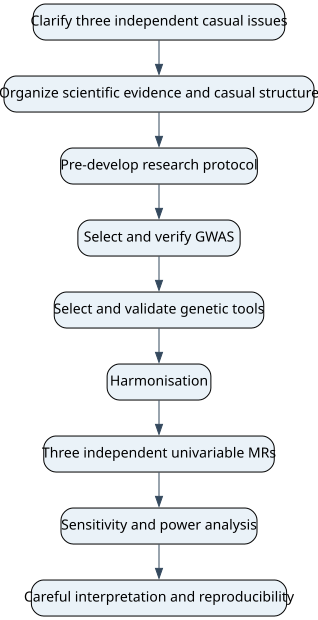

In [70]:
# MR整体流程
from graphviz import Digraph
import shutil
from graphviz import Digraph
dot=Digraph(format='png')
dot.attr('node', shape='box', style='rounded, filled', fillcolor='#EAF2F8', COLOR='#2c3e50', fontname='Arial unicode MS')
dot.attr('edge', color='#34495E', fontname='Arial unicode MS')
dot.node('Q', 'Clarify three independent casual issues')
dot.node('E', 'Organize scientific evidence and casual structure')
dot.node('P', 'Pre-develop research protocol')
dot.node('G','Select and verify GWAS')
dot.node('I','Select and validate genetic tools')
dot.node('H','Harmonisation')
dot.node('M','Three independent univariable MRs')
dot.node('S','Sensitivity and power analysis')
dot.node('R','Careful interpretation and reproducibility')
dot.edge('Q', 'E')
dot.edge('E', 'P')
dot.edge('P', 'G')
dot.edge('G', 'I')
dot.edge('I', 'H')
dot.edge('H', 'M')
dot.edge('M', 'S')
dot.edge('S', 'R')
dot 

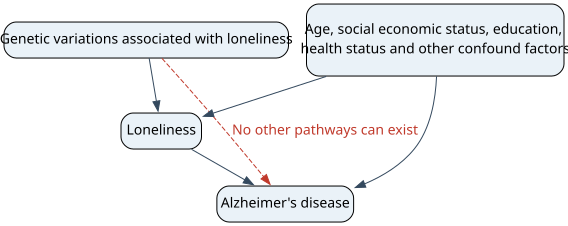

In [69]:
from graphviz import Digraph
import shutil
from graphviz import Digraph
dot=Digraph(format='png')
dot.attr('node', shape='box', style='rounded, filled', fillcolor='#EAF2F8', COLOR='#2c3e50', fontname='Arial unicode MS')
dot.attr('edge', color='#34495E', fontname='Arial unicode MS')
dot.node('G', 'Genetic variations associated with loneliness')
dot.node('X', 'Loneliness')
dot.node('Y', 'Alzheimer\'s disease')
dot.node('C','Age, social economic status, education, ' \
'\nhealth status and other confound factors', height='1', width='1.5')
dot.edge('G', 'X')
dot.edge('X', 'Y')
dot.edge('C', 'X')
dot.edge('C', 'Y')
dot.edge('G', 'Y', label='No other pathways can exist', fontcolor='#C0392B', style='dashed', color='#C0392B', constraint='False')
dot      

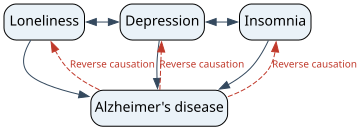

In [68]:
dot=Digraph(format='png')
dot.attr('node', shape='box', style='rounded, filled', fillcolor='#EAF2F8', COLOR='#2c3e50', fontname='Arial unicode MS')
dot.attr('edge', color='#34495E', fontname='Arial unicode MS')
with dot.subgraph() as exposure:
    exposure.attr(rank='same')
    exposure.node('L', 'Loneliness')
    exposure.node('D', 'Depression')
    exposure.node('I', 'Insomnia')
dot.node('A', 'Alzheimer\'s disease')
# 暴露因素之间的双向关系
dot.edge('L', 'D', dir='both', arrowhead='normal', arrowtail='normal')
dot.edge('D', 'I', dir='both', arrowhead='normal', arrowtail='normal')
# 暴露因素对AD的假设效应
dot.edge('L', 'A')
dot.edge('D', 'A')
dot.edge('I', 'A')
# AD可能造成的反向因果
dot.edge('A', 'L', style='dashed', label='Reverse causation', fontcolor='#C0392B', color='#C0392B', fontsize='10')
dot.edge('A', 'D', style='dashed', label='Reverse causation', fontcolor='#C0392B', color='#C0392B', fontsize='10')
dot.edge('A', 'I', style='dashed', label='Reverse causation', fontcolor='#C0392B', color='#C0392B', fontsize='10')
dot  

# 项目1: 心理社会与睡眠
Genetic liability to loneliness, major depression and insomnia and the risk of Alzheimer’s disease: three univariable two-sample Mendelian randomization analyses:
1. Loneliness → AD
2. Major depression → AD
3. Insomnia → AD
4. AD → loneliness/depression/insomnia
# 项目2： 营养与生活活性代谢物
Circulating nutritional biomarkers and Alzheimer’s disease: a two-sample Mendelian randomization study
1. DHA或omega-3
2. Vitamin D

# *Genetic liability to loneliness, major depression and insomnia and the risk of Alzheimer’s disease: three univariable two-sample Mendelian randomization analyses*
## 1. Primary objective: 
To separately estimate the total causal effects of genetic liability to loneliness, major depression and insomnia on the risk of clinically diagnosed Alzheimer’s disease using three univariable two-sample Mendelian randomization analyses.
### Question1: 
Does higher genetic liability to loneliness influence the risk of clinically diagnosed Alzheimer’s disease? (Loneliness→AD)
### Question2:
Does higher genetic liability to major depression influence the risk of clinically diagnosed Alzheimer’s disease? (Major depression→AD)
### Question3:
Does higher genetic liability to insomnia influence the risk of clinically diagnosed Alzheimer’s disease? (Insomnia→AD)
## 2. Hypotheses:
Null hypotheses: 
For each exposure, the null hypothesis is that there is no causal effect on Alzheimer’s disease risk, corresponding to an odds ratio of 1:
>>Loneliness: 
H0: β_Loneliness ->AD=0 (Genetic liability to loneliness has no causal effect on AD risk (OR = 1))
H1: β_Loneliness ->AD>0 (Genetic liability to loneliness has a causal effect on AD risk (OR ≠ 1))
>>Major depression:
H0: β_Depression ->AD=0 (Genetic liability to major depression has no causal effect on AD risk (OR = 1))
H1: β_Depression ->AD>0 (Genetic liability to major depression has a causal effect on AD risk (OR ≠ 1))
>>Insomnia:
H0: β_Insomnia ->AD=0 (Genetic liability to insomnia has no causal effect on AD risk (OR = 1))
H1: β_Insomnia ->AD>0 (Genetic liability to insomnia has a causal effect on AD risk (OR ≠ 1))

Exploratory interpretation:
Because the three exposures are phenotypically and genetically correlated, the univariable analyses will estimate associations for each exposure without conditioning on the other two. Evidence of association will therefore not by itself establish an independent direct effect.

## SNP selection
### High relevance to predict exposure, 
P < 5e-8, LD clumping, r^2<0.001, kb>10000
### Independence, 
SNP should not be relevant with confounder, such as loneliness SNP should not related with education, depression, smoking, BMI, cardiovascular disease, neuroticism, etc
### Exclusion restriction,
such as SNP should only influence AD through exposure than other pathways

# WHY Loneliness?
1. Longitudinal study (Martina etc, Nature mental health, 2024) with 600000 people found that loneliness was associated with an increased risk of dementia, but it is based on observative association, rather casual relationship. National Institute on Aging showed that loneliness increases the overall risk of developing dementia by 31%, raises specific risk for AD by 14%, vascular dementia by 17%, and general cogntie impairment by 15% (2025).
2. Exsiting genetic methods have not established a consistent causal effect. (Roopal et al. 2025)
3. Loneliness may affect brain health through stress, depression, insomnia, inflammation and reduced activity, providing biological plausibility
4. However, preclinical AD may itself lead to social withdrawal and loneliness, creating serious concerns about reverse causation
5. Age, education, health status and socioeconomic circumstances may also confound the association
6. GWAS data and genetic instruments are available for loneliness

# WHY Depression?
1. Longitudinal studies associate depression with increased dementia risk, and the 2024 Lancet Commission identifies depression as a potentially modifiable dementia risk factor (Livingston et al., 2024)
2. PDepression may influence AD through chronic stress, inflammation, sleep disturbance and impaired hippocampal function
3. However, late-life depression may also be an early symptom of preclinical AD
4. Depression and AD may share some genetic susceptibility without having a direct causal relationship
5. Large GWAS datasets and multiple genetic instruments are available for major depression
6. Previous MR studies have produced conflicting results

# WHY Insomnia?
1. Insomnia has been observationally associated with cognitive decline and AD
2. Sleep is involved in memory consolidation, inflammation regulation and brain health, providing a clear biological rationale
3. However, preclinical AD may itself disrupt the sleep–wake system
4. Depression, pain, physical illness and lifestyle factors may contribute to both insomnia and cognitive decline
5. Large GWAS datasets and genetic instruments are available for insomnia
6. MR findings are inconsistent 

# WHY three exposure in one project?
loneliness, major depression and insomnia were selected because they are potentially modifiable psychosocial or sleep-related traits associated with dementia in observational studies. However, their relationships with AD may be affected by confounding, shared genetic susceptibility and reverse causation, as each trait may also emerge during the preclinical phase of AD. The availability of large GWAS datasets and the inconsistency of previous genetic findings make these traits appropriate candidates for Mendelian randomization analysis.

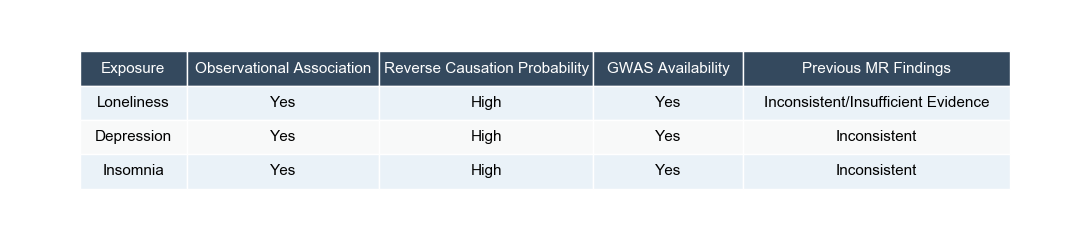

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
data = {
    "Exposure": ["Loneliness", "Depression", "Insomnia"],
    "Observational Association": ["Yes", "Yes", "Yes"],
    "Reverse Causation Probability": ["High", "High", "High"],
    "GWAS Availability": ["Yes", "Yes", "Yes"],
    "Previous MR Findings": [
        "Inconsistent/Insufficient Evidence",
        "Inconsistent",
        "Inconsistent"]}
df = pd.DataFrame(data)
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.axis("off")
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.1, 0.18, 0.20, 0.14, 0.25]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)
for column in range(len(df.columns)):
    cell = table[(0, column)]
    cell.set_facecolor("#34495E")
    cell.set_text_props(color="white", weight="bold")
    cell.set_edgecolor("white")
for row in range(1, len(df) + 1):
    for column in range(len(df.columns)):
        cell = table[(row, column)]
        cell.set_facecolor("#EAF2F8" if row % 2 else "#F8F9F9")
        cell.set_edgecolor("white")
plt.tight_layout()
plt.show()

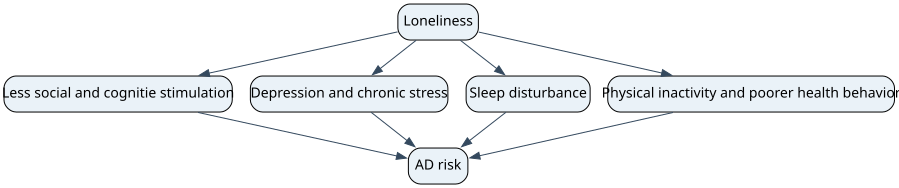

In [61]:
# loneliness -> AD
from graphviz import Digraph
import shutil
from graphviz import Digraph
dot=Digraph(format='png')
dot.attr('node', shape='box', style='rounded, filled', fillcolor='#EAF2F8', COLOR='#2c3e50', fontname='Arial unicode MS')
dot.attr('edge', color='#34495E', fontname='Arial unicode MS')
dot.node('A', 'Loneliness')
dot.node('B', 'Less social and cognitie stimulation')
dot.node('C', 'Depression and chronic stress')
dot.node('D','Sleep disturbance')
dot.node('E','Physical inactivity and poorer health behavior')
dot.node('H','AD risk')
dot.edge('A', 'B')
dot.edge('A', 'C')
dot.edge('A', 'D')
dot.edge('A', 'E')
dot.edge('B', 'H')
dot.edge('C', 'H')
dot.edge('D', 'H')
dot.edge('E', 'H')
dot


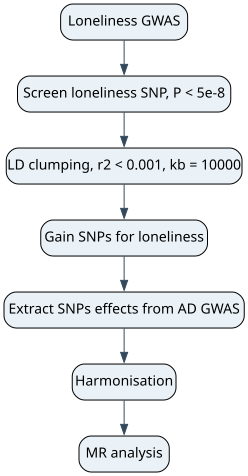

In [ ]:
# procedure
from graphviz import Digraph
import shutil
from graphviz import Digraph
dot=Digraph(format='png')
dot.attr('node', shape='box', style='rounded, filled', fillcolor='#EAF2F8', COLOR='#2c3e50', fontname='Arial unicode MS')
dot.attr('edge', color='#34495E', fontname='Arial unicode MS')
dot.node('A', 'Loneliness GWAS')
dot.node('B', 'Screen loneliness SNP, P < 5e-8')
dot.node('C', 'LD clumping, r2 < 0.001, kb = 10000')
dot.node('D','Gain SNPs for loneliness')
dot.node('E','Extract SNPs effects from AD GWAS')
dot.node('H','Harmonisation')
dot.node('M','MR analysis')
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')
dot.edge('E', 'H')
dot.edge('H', 'M')
dot      